In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

In [2]:
pop_data = pd.read_csv('../data/ibge_manaus_population_data_2016_2024.csv')
pop_data.rename(columns={'index': 'date'}, inplace=True)

# Load IBGE population data (2000-2025) for yearly N
pop_ibge = pd.read_csv('../data/ibge_manaus_rural_population_data_2000_2025.csv')
pop_by_year = dict(zip(pop_ibge['year'], pop_ibge['rural_population']))

In [3]:
climate_data_2003_2004 = pd.read_csv('../data/climate_api_data_aug_2003_jul_2004.csv')
climate_data_2003_2004['date'] = pd.to_datetime(climate_data_2003_2004['date'])

# Extract month and group by it
monthly_avg_temp = climate_data_2003_2004.groupby(climate_data_2003_2004['date'].dt.month)['temp_med'].mean()

# Rename index to month names
monthly_avg_temp.index = ['January', 'February', 'March', 'April', 'May', 'June', 
                          'July', 'August', 'September', 'October', 'November', 'December']

monthly_avg_temp

January      26.493410
February     25.671248
March        25.452055
April        25.667657
May          25.311058
June         25.107737
July         25.185835
August       25.774655
September    25.898173
October      26.671094
November     26.334383
December     26.297168
Name: temp_med, dtype: float64

Given that all of our information regarding biting rate is related to the original paper from Parham & Michael (2010), it was decided to use separate data related to the biology of Anopheles in the Amazon in order to better approximate proper values for $T'$ and $D_1$.

According to Lardeaux et al (2008), we have that

$$P=Q^{1/g} \Longleftrightarrow P^g=Q$$

Where $P$ is the daily survival rate of mosquitos, $Q$ is the proportion of parous mosquitoes females in the population and $g$ is the duration of the gonotrophic cycle in days (Davidson's Formula).

Now, according to de Barros, Honório and Arruda (2011), we have the following table, of the number of nulliparous and parous An. darlingi females dissected in different collection periods, from August 2003 to July 2004:

In [7]:
# ============================================================
# An. darlingi dissection data
# From August 2003 to July 2004
# ============================================================

data = pd.DataFrame({
    'Month':     ['Aug', 'Nov', 'Jan', 'Mar', 'May', 'Jul'],
    'nullip':  [53,    54,    30,    50,    48,    185  ],
    'parous':  [17,    24,    114,   47,    65,    69   ],
    'total':   [70,    78,    144,   97,    113,   254  ],
    'Q':       [0.25,  0.31,  0.80,  0.48,  0.57,  0.27],   # parous proportion
    'P':       [0.524, 0.571, 0.911, 0.742, 0.812, 0.557],  # daily survival rate
    'EIP':     [8.14,  7.34,  7.29,  7.24,  8.68,  9.13],   # sporogonic cycle of P. vivax in days
    'HBR':     [0.72,  0.84,  4.08,  5.64,  6.24,  0.60],   # mean biting density (mosquitoes/person/day)
    'HBR_inf': [0.004, 0.014, 2.057, 0.650, 0.866, 0.003],  # estimated mean biting density of mosquitoes surviving >1 sporogonic cycle 
})

data['Temp'] = [np.round(monthly_avg_temp['August'],1),
                np.round(monthly_avg_temp['November'],1),
                np.round(monthly_avg_temp['January'],1),
                np.round(monthly_avg_temp['March'],1),
                np.round(monthly_avg_temp['May'],1),
                np.round(monthly_avg_temp['July'],1)]

T_prime = 16.0  # Minimum temperature below which there is no development of the vector (Mordecai et al. 2013)

In [8]:
data

,Month,nullip,parous,total,Q,P,EIP,HBR,HBR_inf,Temp
0,Aug,53,17,70,0.25,0.524,8.14,0.72,0.004,25.8
1,Nov,54,24,78,0.31,0.571,7.34,0.84,0.014,26.3
2,Jan,30,114,144,0.80,0.911,7.29,4.08,2.057,26.5
3,Mar,50,47,97,0.48,0.742,7.24,5.64,0.650,25.5
4,May,48,65,113,0.57,0.812,8.68,6.24,0.866,25.3
5,Jul,185,69,254,0.27,0.557,9.13,0.60,0.003,25.2


In [9]:
# ============================================================
# STEP 1: Estimate g using Davidson's formula: Q = P^g  =>  g = ln(Q) / ln(P)
# ============================================================

data['g'] = np.log(data['Q']) / np.log(data['P'])

print("=" * 70)
print("Gonotrophic cycle duration: g = ln(Q) / ln(P)")
print("=" * 70)
for _, row in data.iterrows():
    print(f"  {row['Month']:4s}: Q = {row['Q']:.2f}, P = {row['P']:.3f} "
          f"→ g = {row['g']:.2f} days")

Gonotrophic cycle duration: g = ln(Q) / ln(P)
  Aug : Q = 0.25, P = 0.524 → g = 2.15 days
  Nov : Q = 0.31, P = 0.571 → g = 2.09 days
  Jan : Q = 0.80, P = 0.911 → g = 2.39 days
  Mar : Q = 0.48, P = 0.742 → g = 2.46 days
  May : Q = 0.57, P = 0.812 → g = 2.70 days
  Jul : Q = 0.27, P = 0.557 → g = 2.24 days


In [10]:
# ============================================================
# STEP 2: Estimate D1 = g × (T − T')  (Gonotrophic cycle is the inverse of the biting rate)
# ============================================================

data['D1'] = data['g'] * (data['Temp'] - T_prime)

D1_avg = data['D1'].mean()
D1_std = data['D1'].std()
D1_cv = D1_std / D1_avg * 100 # (Coefficient of Variation)

print(f"\n{'=' * 70}")
print("Estimating D1 = g × (T − T')")
print(f"{'=' * 70}")
for _, row in data.iterrows():
    print(f"  {row['Month']:4s}: g = {row['g']:.2f}, T = {row['Temp']:.1f}°C, "
          f"(T − T') = {row['Temp'] - T_prime:.1f} → D1 = {row['D1']:.1f}°C·days")
print(f"\n  Mean D1 = {D1_avg:.1f} ± {D1_std:.1f}°C·days (CV = {D1_cv:.1f}%)")


Estimating D1 = g × (T − T')
  Aug : g = 2.15, T = 25.8°C, (T − T') = 9.8 → D1 = 21.0°C·days
  Nov : g = 2.09, T = 26.3°C, (T − T') = 10.3 → D1 = 21.5°C·days
  Jan : g = 2.39, T = 26.5°C, (T − T') = 10.5 → D1 = 25.1°C·days
  Mar : g = 2.46, T = 25.5°C, (T − T') = 9.5 → D1 = 23.4°C·days
  May : g = 2.70, T = 25.3°C, (T − T') = 9.3 → D1 = 25.1°C·days
  Jul : g = 2.24, T = 25.2°C, (T − T') = 9.2 → D1 = 20.6°C·days

  Mean D1 = 22.8 ± 2.0°C·days (CV = 8.9%)


In [11]:
# ============================================================
# STEP 3: Calculate a(T) and m (ratio of female mosquitoes to humans)
# ============================================================

data['a_T'] = (data['Temp'] - T_prime) / D1_avg
data['m'] = data['HBR'] / data['a_T']

print(f"\n{'=' * 70}")
print(f"a(T) = (T − {T_prime}) / {D1_avg:.1f} e m = HBR / a(T)")
print(f"{'=' * 70}")
for _, row in data.iterrows():
    print(f"  {row['Month']:4s}: T = {row['Temp']:.1f}°C, a(T) = {row['a_T']:.3f}, "
          f"HBR = {row['HBR']:.2f} → m = {row['m']:.1f} females/human")


a(T) = (T − 16.0) / 22.8 e m = HBR / a(T)
  Aug : T = 25.8°C, a(T) = 0.430, HBR = 0.72 → m = 1.7 females/human
  Nov : T = 26.3°C, a(T) = 0.452, HBR = 0.84 → m = 1.9 females/human
  Jan : T = 26.5°C, a(T) = 0.461, HBR = 4.08 → m = 8.9 females/human
  Mar : T = 25.5°C, a(T) = 0.417, HBR = 5.64 → m = 13.5 females/human
  May : T = 25.3°C, a(T) = 0.408, HBR = 6.24 → m = 15.3 females/human
  Jul : T = 25.2°C, a(T) = 0.404, HBR = 0.60 → m = 1.5 females/human


In [12]:
# ============================================================
# STEP 4: Calculate mu(T) and E/I ratio, where mu(T)=-\ln(P) and E/I, 
# in the steady state, and using our equations, is given by mu/(b3*l), that is
# equal to E/I = mu * EIP * exp(mu * EIP)
# ============================================================

data['mu_T'] = -np.log(data['P'])
data['E/I'] = data['mu_T'] * data['EIP'] * np.exp(data['mu_T'] * data['EIP'])

print(f"\n{'=' * 70}")
print("Estimating mu = -ln(P) and E/I = mu*EIP*exp(mu*EIP)")
print(f"{'=' * 70}")
for _, row in data.iterrows():
    print(f"  {row['Month']:4s}: T = {row['Temp']:.1f}°C, mu(T) = {row['mu_T']:.3f}, "
          f"EIP = {row['EIP']:.2f} → E/I = {row['E/I']:.1f} exposed/infected")


Estimating mu = -ln(P) and E/I = mu*EIP*exp(mu*EIP)
  Aug : T = 25.8°C, mu(T) = 0.646, EIP = 8.14 → E/I = 1013.2 exposed/infected
  Nov : T = 26.3°C, mu(T) = 0.560, EIP = 7.34 → E/I = 251.5 exposed/infected
  Jan : T = 26.5°C, mu(T) = 0.093, EIP = 7.29 → E/I = 1.3 exposed/infected
  Mar : T = 25.5°C, mu(T) = 0.298, EIP = 7.24 → E/I = 18.7 exposed/infected
  May : T = 25.3°C, mu(T) = 0.208, EIP = 8.68 → E/I = 11.0 exposed/infected
  Jul : T = 25.2°C, mu(T) = 0.585, EIP = 9.13 → E/I = 1117.1 exposed/infected


In [13]:
# ============================================================
# Summary
# ============================================================

print(f"\n{'=' * 70}")
print("Summary of calibrated parameters")
print(f"{'=' * 70}")
print(f"  T' = {T_prime:.1f}°C (Mordecai et al. 2013)")
print(f"  D1 = {D1_avg:.1f}°C·days (derived from de Barros, Honório and Arruda (2011))")
print(f"  Average duration of the gonotrophic cycle: {data['g'].mean():.2f} days")
print(f"  Range of biting rate: {data['a_T'].min():.3f} - {data['a_T'].max():.3f} bites/mosquito/day")
print(f"  Range of females/humans ratio: {data['m'].min():.1f} - {data['m'].max():.1f} females/human")
print(f"  Range of biting density: {data['HBR'].min():.2f} - {data['HBR'].max():.2f} bites/person/day")
print(f"  Range of mortality: {data['mu_T'].min():.2f} - {data['mu_T'].max():.2f} deaths/mosquito/day")
print(f"  Range of exposed/infected ratio: {data['E/I'].min():.2f} - {data['E/I'].max():.2f} exposed/infected")


Summary of calibrated parameters
  T' = 16.0°C (Mordecai et al. 2013)
  D1 = 22.8°C·days (derived from de Barros, Honório and Arruda (2011))
  Average duration of the gonotrophic cycle: 2.34 days
  Range of biting rate: 0.404 - 0.461 bites/mosquito/day
  Range of females/humans ratio: 1.5 - 15.3 females/human
  Range of biting density: 0.60 - 6.24 bites/person/day
  Range of mortality: 0.09 - 0.65 deaths/mosquito/day
  Range of exposed/infected ratio: 1.34 - 1117.15 exposed/infected


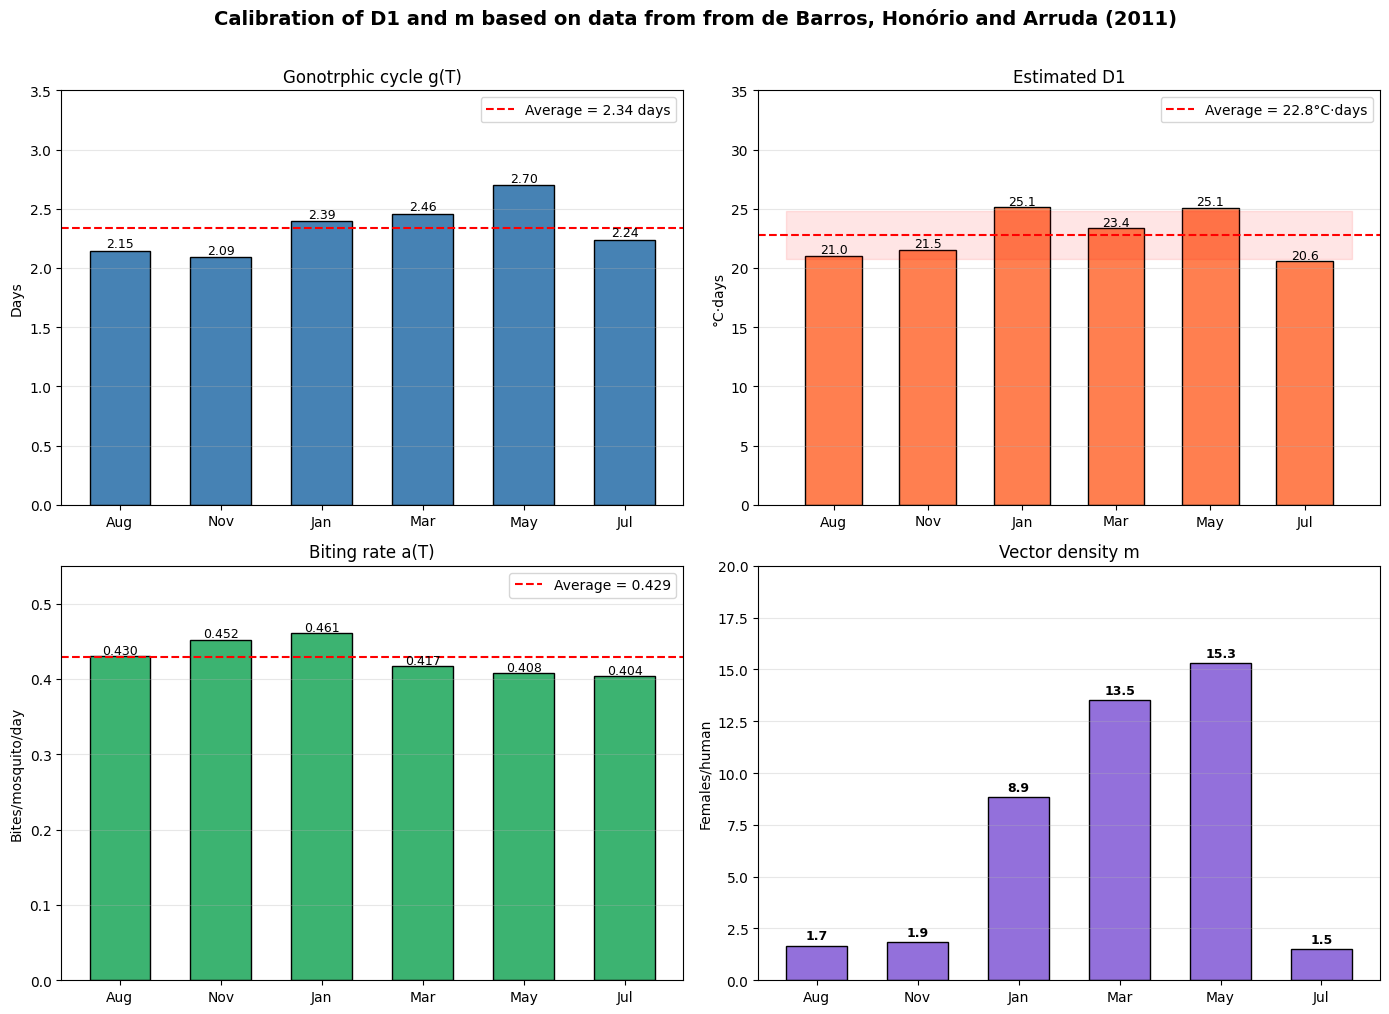

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

months = data['Month'].values
x = np.arange(len(months))

# --- A) Gonotrphic cycle ---
ax = axes[0, 0]
bars = ax.bar(x, data['g'], color='steelblue', edgecolor='black', width=0.6)
ax.axhline(data['g'].mean(), color='red', ls='--', lw=1.5,
           label=f'Average = {data["g"].mean():.2f} days')
for bar, val in zip(bars, data['g']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('Days'); ax.set_title('Gonotrphic cycle g(T)')
ax.legend(); ax.set_ylim(0, 3.5); ax.grid(axis='y', alpha=0.3)

# --- B) D1 ---
ax = axes[0, 1]
bars = ax.bar(x, data['D1'], color='coral', edgecolor='black', width=0.6)
ax.axhline(D1_avg, color='red', ls='--', lw=1.5,
           label=f'Average = {D1_avg:.1f}°C·days')
ax.fill_between([-0.5, 5.5], D1_avg - D1_std, D1_avg + D1_std,
                color='red', alpha=0.1)
for bar, val in zip(bars, data['D1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('°C·days'); ax.set_title('Estimated D1')
ax.legend(); ax.set_ylim(0, 35); ax.grid(axis='y', alpha=0.3)

# --- C) a(T) ---
ax = axes[1, 0]
bars = ax.bar(x, data['a_T'], color='mediumseagreen', edgecolor='black', width=0.6)
ax.axhline(data['a_T'].mean(), color='red', ls='--', lw=1.5,
           label=f'Average = {data["a_T"].mean():.3f}')
for bar, val in zip(bars, data['a_T']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('Bites/mosquito/day'); ax.set_title('Biting rate a(T)')
ax.legend(); ax.set_ylim(0, 0.55); ax.grid(axis='y', alpha=0.3)

# --- D) m (vector density) ---
ax = axes[1, 1]
bars = ax.bar(x, data['m'], color='mediumpurple', edgecolor='black', width=0.6)
for bar, val in zip(bars, data['m']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('Females/human'); ax.set_title('Vector density m')
ax.set_ylim(0, 20); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Calibration of D1 and m based on data from from de Barros, Honório and Arruda (2011)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('calibracao_D1_an_darlingi.png', dpi=150, bbox_inches='tight')
plt.show()

### ---------------------------------------------------------------------------------------- ###

In [16]:
climate_data = pd.read_csv('../data/climate_api_data_2016_2024.csv')
climate_data['date'] = pd.to_datetime(climate_data['date'])

# Extract month and group by it
monthly_avg_temp = climate_data.groupby(climate_data['date'].dt.month)['temp_med'].mean()

# Rename index to month names
monthly_avg_temp.index = ['January', 'February', 'March', 'April', 'May', 'June', 
                          'July', 'August', 'September', 'October', 'November', 'December']

monthly_avg_temp

January      26.263819
February     26.152284
March        26.182931
April        25.963312
May          26.028870
June         26.055624
July         26.592013
August       27.600084
September    28.172389
October      28.177770
November     27.366477
December     26.192548
Name: temp_med, dtype: float64

In [17]:
# ============================================================
# An. darlingi dissection data
# From August 2003 to July 2004, but using average temperatures 
# from 2016 to 2024 to analyze the effects of the change in temperature
# ============================================================

data = pd.DataFrame({
    'Month':     ['Aug', 'Nov', 'Jan', 'Mar', 'May', 'Jul'],
    'nullip':  [53,    54,    30,    50,    48,    185  ],
    'parous':  [17,    24,    114,   47,    65,    69   ],
    'total':   [70,    78,    144,   97,    113,   254  ],
    'Q':       [0.25,  0.31,  0.80,  0.48,  0.57,  0.27],   # parous proportion
    'P':       [0.524, 0.571, 0.911, 0.742, 0.812, 0.557],  # daily survival rate
    'EIP':     [8.14,  7.34,  7.29,  7.24,  8.68,  9.13],   # sporogonic cycle of P. vivax in days
    'HBR':     [0.72,  0.84,  4.08,  5.64,  6.24,  0.60],   # mean biting density (mosquitoes/person/day)
    'HBR_inf': [0.004, 0.014, 2.057, 0.650, 0.866, 0.003],  # estimated mean biting density of mosquitoes surviving >1 sporogonic cycle 
})

data['Temp'] = [np.round(monthly_avg_temp['August'],1),
                np.round(monthly_avg_temp['November'],1),
                np.round(monthly_avg_temp['January'],1),
                np.round(monthly_avg_temp['March'],1),
                np.round(monthly_avg_temp['May'],1),
                np.round(monthly_avg_temp['July'],1)]

T_prime = 16.0  # Minimum temperature below which there is no development of the vector (Mordecai et al. 2013)

In [18]:
# ============================================================
# STEP 1: Estimate g using Davidson's formula: Q = P^g  =>  g = ln(Q) / ln(P)
# ============================================================

data['g'] = np.log(data['Q']) / np.log(data['P'])

print("=" * 70)
print("Gonotrophic cycle duration: g = ln(Q) / ln(P)")
print("=" * 70)
for _, row in data.iterrows():
    print(f"  {row['Month']:4s}: Q = {row['Q']:.2f}, P = {row['P']:.3f} "
          f"→ g = {row['g']:.2f} days")

Gonotrophic cycle duration: g = ln(Q) / ln(P)
  Aug : Q = 0.25, P = 0.524 → g = 2.15 days
  Nov : Q = 0.31, P = 0.571 → g = 2.09 days
  Jan : Q = 0.80, P = 0.911 → g = 2.39 days
  Mar : Q = 0.48, P = 0.742 → g = 2.46 days
  May : Q = 0.57, P = 0.812 → g = 2.70 days
  Jul : Q = 0.27, P = 0.557 → g = 2.24 days


In [19]:
# ============================================================
# STEP 2: Estimate D1 = g × (T − T')  (Gonotrophic cycle is the inverse of the biting rate)
# ============================================================

data['D1'] = data['g'] * (data['Temp'] - T_prime)

D1_avg = data['D1'].mean()
D1_std = data['D1'].std()
D1_cv = D1_std / D1_avg * 100 # (Coefficient of Variation)

print(f"\n{'=' * 70}")
print("Estimating D1 = g × (T − T')")
print(f"{'=' * 70}")
for _, row in data.iterrows():
    print(f"  {row['Month']:4s}: g = {row['g']:.2f}, T = {row['Temp']:.1f}°C, "
          f"(T − T') = {row['Temp'] - T_prime:.1f} → D1 = {row['D1']:.1f}°C·days")
print(f"\n  Mean D1 = {D1_avg:.1f} ± {D1_std:.1f}°C·days (CV = {D1_cv:.1f}%)")


Estimating D1 = g × (T − T')
  Aug : g = 2.15, T = 27.6°C, (T − T') = 11.6 → D1 = 24.9°C·days
  Nov : g = 2.09, T = 27.4°C, (T − T') = 11.4 → D1 = 23.8°C·days
  Jan : g = 2.39, T = 26.3°C, (T − T') = 10.3 → D1 = 24.7°C·days
  Mar : g = 2.46, T = 26.2°C, (T − T') = 10.2 → D1 = 25.1°C·days
  May : g = 2.70, T = 26.0°C, (T − T') = 10.0 → D1 = 27.0°C·days
  Jul : g = 2.24, T = 26.6°C, (T − T') = 10.6 → D1 = 23.7°C·days

  Mean D1 = 24.9 ± 1.2°C·days (CV = 4.8%)


In [20]:
# ============================================================
# STEP 3: Calculate a(T) e m (ratio of female mosquitoes to humans)
# ============================================================

data['a_T'] = (data['Temp'] - T_prime) / D1_avg
data['m'] = data['HBR'] / data['a_T']

print(f"\n{'=' * 70}")
print(f"a(T) = (T − {T_prime}) / {D1_avg:.1f} e m = HBR / a(T)")
print(f"{'=' * 70}")
for _, row in data.iterrows():
    print(f"  {row['Month']:4s}: T = {row['Temp']:.1f}°C, a(T) = {row['a_T']:.3f}, "
          f"HBR = {row['HBR']:.2f} → m = {row['m']:.1f} females/human")


a(T) = (T − 16.0) / 24.9 e m = HBR / a(T)
  Aug : T = 27.6°C, a(T) = 0.467, HBR = 0.72 → m = 1.5 females/human
  Nov : T = 27.4°C, a(T) = 0.459, HBR = 0.84 → m = 1.8 females/human
  Jan : T = 26.3°C, a(T) = 0.414, HBR = 4.08 → m = 9.8 females/human
  Mar : T = 26.2°C, a(T) = 0.410, HBR = 5.64 → m = 13.7 females/human
  May : T = 26.0°C, a(T) = 0.402, HBR = 6.24 → m = 15.5 females/human
  Jul : T = 26.6°C, a(T) = 0.426, HBR = 0.60 → m = 1.4 females/human


In [21]:
# ============================================================
# STEP 4: Calculate mu(T) and E/I ratio, where mu(T)=-\ln(P) and E/I, 
# in the steady state, and using our equations, is given by mu/(b3*l), that is
# equal to E/I = mu * EIP * exp(mu * EIP)
# ============================================================

data['mu_T'] = -np.log(data['P'])
data['E/I'] = data['mu_T'] * data['EIP'] * np.exp(data['mu_T'] * data['EIP'])

print(f"\n{'=' * 70}")
print("Estimating mu = -ln(P) and E/I = mu*EIP*exp(mu*EIP)")
print(f"{'=' * 70}")
for _, row in data.iterrows():
    print(f"  {row['Month']:4s}: T = {row['Temp']:.1f}°C, mu(T) = {row['mu_T']:.3f}, "
          f"EIP = {row['EIP']:.2f} → E/I = {row['E/I']:.1f} exposed/infected")


Estimating mu = -ln(P) and E/I = mu*EIP*exp(mu*EIP)
  Aug : T = 27.6°C, mu(T) = 0.646, EIP = 8.14 → E/I = 1013.2 exposed/infected
  Nov : T = 27.4°C, mu(T) = 0.560, EIP = 7.34 → E/I = 251.5 exposed/infected
  Jan : T = 26.3°C, mu(T) = 0.093, EIP = 7.29 → E/I = 1.3 exposed/infected
  Mar : T = 26.2°C, mu(T) = 0.298, EIP = 7.24 → E/I = 18.7 exposed/infected
  May : T = 26.0°C, mu(T) = 0.208, EIP = 8.68 → E/I = 11.0 exposed/infected
  Jul : T = 26.6°C, mu(T) = 0.585, EIP = 9.13 → E/I = 1117.1 exposed/infected


In [22]:
# ============================================================
# Summary
# ============================================================

print(f"\n{'=' * 70}")
print("Summary of calibrated parameters")
print(f"{'=' * 70}")
print(f"  T' = {T_prime:.1f}°C (Mordecai et al. 2013)")
print(f"  D1 = {D1_avg:.1f}°C·days (derived from de Barros, Honório and Arruda (2011))")
print(f"  Average duration of the gonotrophic cycle: {data['g'].mean():.2f} days")
print(f"  Range of biting rate: {data['a_T'].min():.3f} - {data['a_T'].max():.3f} bites/mosquito/day")
print(f"  Range of females/humans ratio: {data['m'].min():.1f} - {data['m'].max():.1f} females/human")
print(f"  Range of biting density: {data['HBR'].min():.2f} - {data['HBR'].max():.2f} bites/person/day")
print(f"  Range of mortality: {data['mu_T'].min():.2f} - {data['mu_T'].max():.2f} deaths/mosquito/day")
print(f"  Range of exposed/infected ratio: {data['E/I'].min():.2f} - {data['E/I'].max():.2f} exposed/infected")


Summary of calibrated parameters
  T' = 16.0°C (Mordecai et al. 2013)
  D1 = 24.9°C·days (derived from de Barros, Honório and Arruda (2011))
  Average duration of the gonotrophic cycle: 2.34 days
  Range of biting rate: 0.402 - 0.467 bites/mosquito/day
  Range of females/humans ratio: 1.4 - 15.5 females/human
  Range of biting density: 0.60 - 6.24 bites/person/day
  Range of mortality: 0.09 - 0.65 deaths/mosquito/day
  Range of exposed/infected ratio: 1.34 - 1117.15 exposed/infected


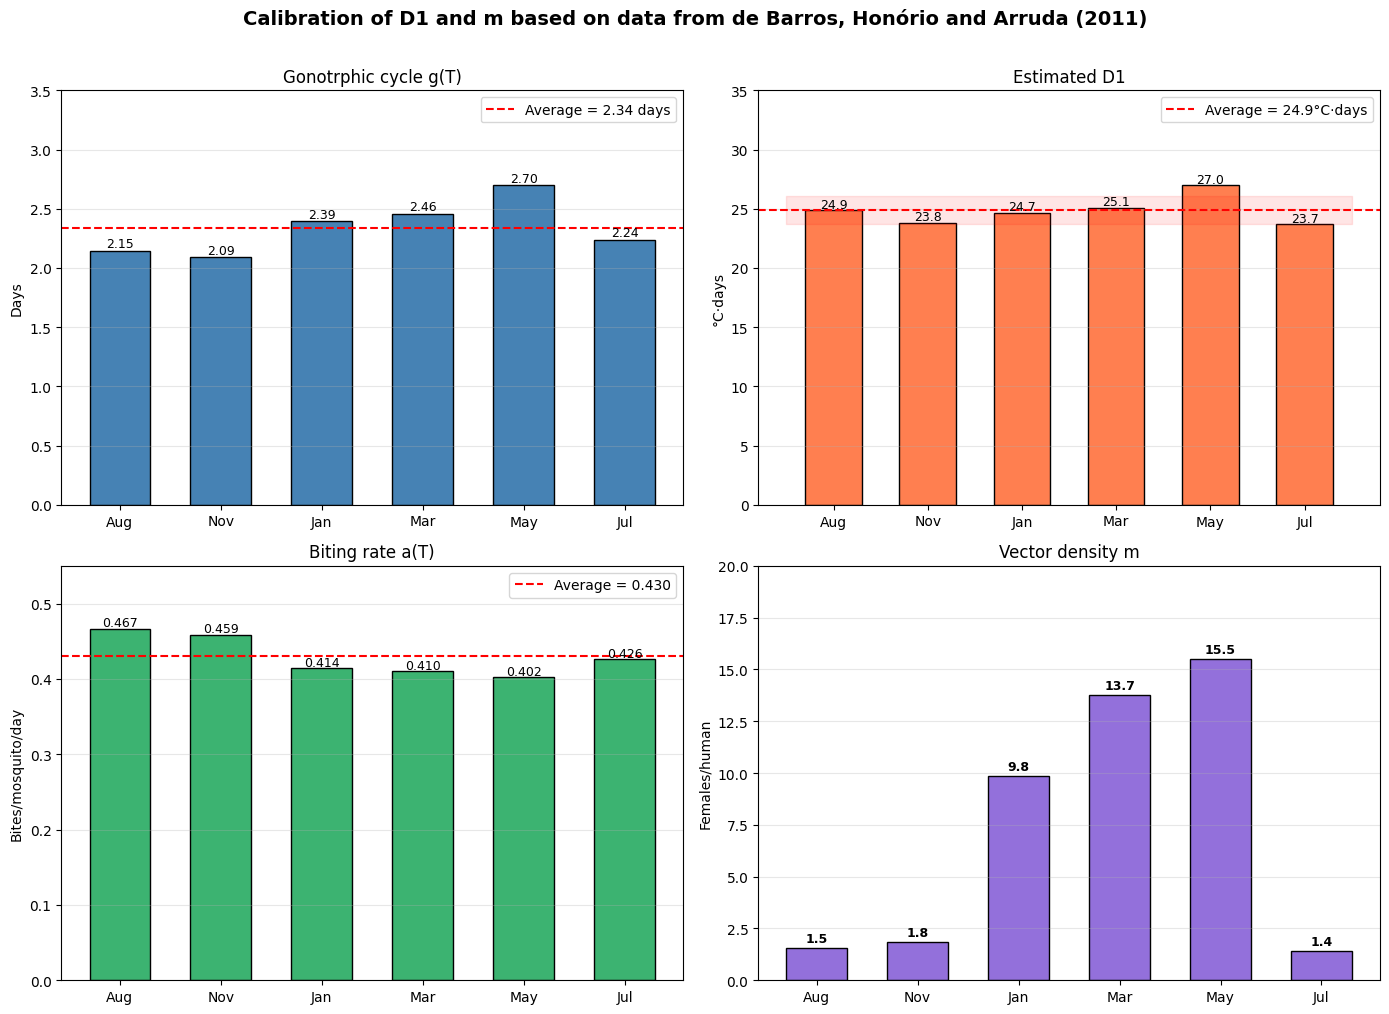

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

months = data['Month'].values
x = np.arange(len(months))

# --- A) Gonotrphic cycle ---
ax = axes[0, 0]
bars = ax.bar(x, data['g'], color='steelblue', edgecolor='black', width=0.6)
ax.axhline(data['g'].mean(), color='red', ls='--', lw=1.5,
           label=f'Average = {data["g"].mean():.2f} days')
for bar, val in zip(bars, data['g']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('Days'); ax.set_title('Gonotrphic cycle g(T)')
ax.legend(); ax.set_ylim(0, 3.5); ax.grid(axis='y', alpha=0.3)

# --- B) D1 ---
ax = axes[0, 1]
bars = ax.bar(x, data['D1'], color='coral', edgecolor='black', width=0.6)
ax.axhline(D1_avg, color='red', ls='--', lw=1.5,
           label=f'Average = {D1_avg:.1f}°C·days')
ax.fill_between([-0.5, 5.5], D1_avg - D1_std, D1_avg + D1_std,
                color='red', alpha=0.1)
for bar, val in zip(bars, data['D1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('°C·days'); ax.set_title('Estimated D1')
ax.legend(); ax.set_ylim(0, 35); ax.grid(axis='y', alpha=0.3)

# --- C) a(T) ---
ax = axes[1, 0]
bars = ax.bar(x, data['a_T'], color='mediumseagreen', edgecolor='black', width=0.6)
ax.axhline(data['a_T'].mean(), color='red', ls='--', lw=1.5,
           label=f'Average = {data["a_T"].mean():.3f}')
for bar, val in zip(bars, data['a_T']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('Bites/mosquito/day'); ax.set_title('Biting rate a(T)')
ax.legend(); ax.set_ylim(0, 0.55); ax.grid(axis='y', alpha=0.3)

# --- D) m (vector density) ---
ax = axes[1, 1]
bars = ax.bar(x, data['m'], color='mediumpurple', edgecolor='black', width=0.6)
for bar, val in zip(bars, data['m']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_ylabel('Females/human'); ax.set_title('Vector density m')
ax.set_ylim(0, 20); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Calibration of D1 and m based on data from de Barros, Honório and Arruda (2011)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### ---------------------------------------------------------------------------------------- ###

In [25]:
data

,Month,nullip,parous,total,Q,P,EIP,HBR,HBR_inf,Temp,g,D1,a_T,m,mu_T,E/I
0,Aug,53,17,70,0.25,0.524,8.14,0.72,0.004,27.6,2.145091,24.883058,0.466601,1.543075,0.646264,1013.158566
1,Nov,54,24,78,0.31,0.571,7.34,0.84,0.014,27.4,2.090032,23.826364,0.458556,1.831838,0.560366,251.454178
2,Jan,30,114,144,0.80,0.911,7.29,4.08,2.057,26.3,2.393926,24.657439,0.414309,9.847717,0.093212,1.340640
3,Mar,50,47,97,0.48,0.742,7.24,5.64,0.650,26.2,2.459632,25.088251,0.410287,13.746481,0.298406,18.742257
4,May,48,65,113,0.57,0.812,8.68,6.24,0.866,26.0,2.699186,26.991865,0.402242,15.513050,0.208255,11.019673
5,Jul,185,69,254,0.27,0.557,9.13,0.60,0.003,26.6,2.237450,23.716968,0.426376,1.407207,0.585190,1117.145578


Re-estimating D1 with interpolated months

Month  T (°C)  g (days)  (T−T')       D1          Source
-------------------------------------------------------
  Aug    27.60      2.15   11.60     24.9   observed
  Sep    28.17      2.08   12.17     25.3   interpolated
  Oct    28.18      2.04   12.18     24.9   interpolated
  Nov    27.37      2.09   11.37     23.8   observed
  Dec    26.19      2.25   10.19     22.9   interpolated
  Jan    26.26      2.39   10.26     24.6   observed
  Feb    26.15      2.42   10.15     24.6   interpolated
  Mar    26.18      2.46   10.18     25.0   observed
  Apr    25.96      2.62    9.96     26.1   interpolated
  May    26.03      2.70   10.03     27.1   observed
  Jun    26.06      2.50   10.06     25.1   interpolated
  Jul    26.59      2.24   10.59     23.7   observed

  Previous D1 (Observed months only): 24.9 ± 1.2 °C·days
  Re-estimated D1 (All 12 months): 24.8 ± 1.1 °C·days
  Change: 0.0 °C·days (0.1%)

Comparing old vs re-estimated D1
Month   m

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


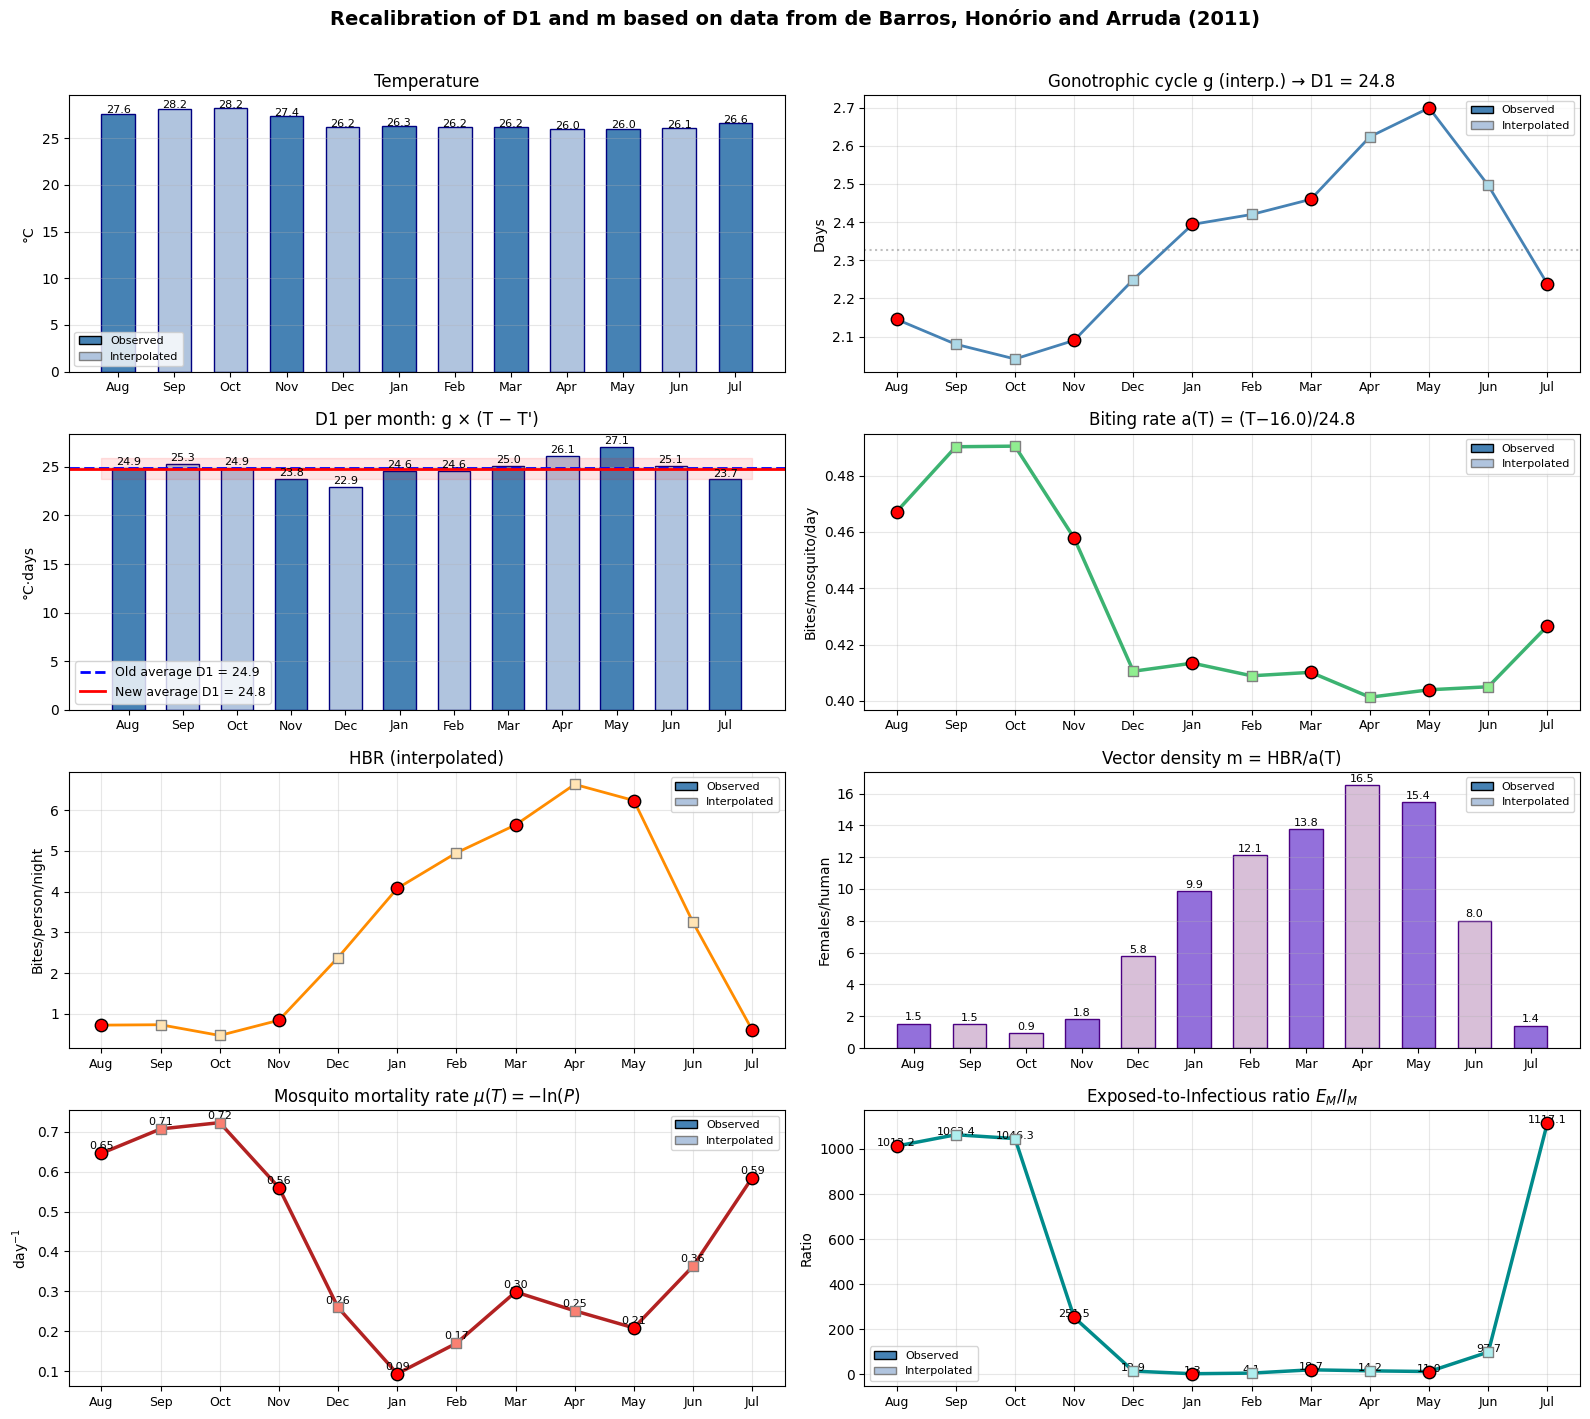

In [49]:
# ============================================================
# STEP 5: Re-estimating D1 using all 12 months
# ============================================================

# Annual cycle: Aug=0, Sep=1, ..., Jul=11
month_names_12 = ['Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul']
month_nums_12  = np.arange(12)
obs_idx = [0, 3, 5, 7, 9, 11]  # Aug, Nov, Jan, Mar, May, Jul

# --- 5a: Observed g (already computed in data['g']) ---
obs_g = data['g'].values  # 6 observed values

print("=" * 65)
print("Re-estimating D1 with interpolated months")
print("=" * 65)

# --- 5b: Interpolate g with periodic cubic spline ---
ext_idx = np.append(obs_idx, 12)
cs_g = CubicSpline(ext_idx, np.append(obs_g, obs_g[0]), bc_type='periodic')
g_12 = cs_g(month_nums_12)

# g must be positive
g_12 = np.clip(g_12, 0.5, None)

# --- 5c: All 12 temperatures ---
T_12 = np.array([
    monthly_avg_temp['August'],    monthly_avg_temp['September'],
    monthly_avg_temp['October'],   monthly_avg_temp['November'],
    monthly_avg_temp['December'],  monthly_avg_temp['January'],
    monthly_avg_temp['February'],  monthly_avg_temp['March'],
    monthly_avg_temp['April'],     monthly_avg_temp['May'],
    monthly_avg_temp['June'],      monthly_avg_temp['July']
])

# --- 5d: Re-estimate D1 for each month ---
D1_12 = g_12 * (T_12 - T_prime)

D1_12_avg = D1_12.mean()
D1_12_std = D1_12.std()

print(f"\n{'Month':5s} {'T (°C)':>7s} {'g (days)':>9s} {'(T−T\')':>7s} {'D1':>8s} {'Source':>15s}")
print("-" * 55)
for i in range(12):
    src = "observed" if i in obs_idx else "interpolated"
    print(f"  {month_names_12[i]:3s}  {T_12[i]:7.2f} {g_12[i]:9.2f} "
          f"{T_12[i] - T_prime:7.2f} {D1_12[i]:8.1f}   {src}")

print(f"\n  Previous D1 (Observed months only): {D1_avg:.1f} ± {D1_std:.1f} °C·days")
print(f"  Re-estimated D1 (All 12 months): {D1_12_avg:.1f} ± {D1_12_std:.1f} °C·days")
print(f"  Change: {abs(D1_12_avg - D1_avg):.1f} °C·days ({abs(D1_12_avg - D1_avg)/D1_avg*100:.1f}%)")

# ============================================================
# STEP 6: Recalculate everything with new D1
# ============================================================

# Interpolate HBR, P, EIP 
obs_HBR = data['HBR'].values
obs_P   = data['P'].values
obs_EIP = data['EIP'].values

cs_HBR = CubicSpline(ext_idx, np.append(obs_HBR, obs_HBR[0]), bc_type='periodic')
cs_P   = CubicSpline(ext_idx, np.append(obs_P,   obs_P[0]),   bc_type='periodic')
cs_EIP = CubicSpline(ext_idx, np.append(obs_EIP, obs_EIP[0]), bc_type='periodic')

HBR_12 = np.clip(cs_HBR(month_nums_12), 0, None)
P_12   = np.clip(cs_P(month_nums_12),   0.01, 0.999)
EIP_12 = np.clip(cs_EIP(month_nums_12), 1, None)

a_12     = (T_12 - T_prime) / D1_12_avg      # biting rate
g_12_m   = D1_12_avg / (T_12 - T_prime)      # gonotrophic cycle (from model)
m_12     = HBR_12 / a_12                     # vector density

mu_12 = -np.log(P_12)
E_to_I_12 = mu_12*EIP_12*np.exp(mu_12*EIP_12)

# Compare old vs new
print(f"\n{'=' * 75}")
print("Comparing old vs re-estimated D1")
print(f"{'=' * 75}")
print(f"{'Month':5s} {'m_old':>7s} {'m_new':>7s} {'a_old':>7s} {'a_new':>7s} "
      f"{'g_old':>7s} {'g_new':>7s}")
print("-" * 55)

a_old = (T_12 - T_prime) / D1_avg
m_old = HBR_12 / a_old
g_old = D1_avg / (T_12 - T_prime)

for i in range(12):
    print(f"  {month_names_12[i]:3s} {m_old[i]:7.1f} {m_12[i]:7.1f} "
          f"{a_old[i]:7.3f} {a_12[i]:7.3f} {g_old[i]:7.2f} {g_12_m[i]:7.2f}")

# ============================================================
# STEP 7: Final summary table
# ============================================================

is_obs = [i in obs_idx for i in month_nums_12]

df_full = pd.DataFrame({
    'Month':      month_names_12,
    'T (°C)':     np.round(T_12, 2),
    'g (days)':   np.round(g_12, 2),         # interpolated from Davidson
    'D1 (°C·days)':  np.round(D1_12, 1),
    'a(T)':       np.round(a_12, 3),
    'g_model':    np.round(g_12_m, 2),        # from model D1/(T-T')
    'P':          np.round(P_12, 3),
    'HBR':        np.round(HBR_12, 2),
    'EIP (days)': np.round(EIP_12, 2),
    'm':          np.round(m_12, 1),
    'mu(T)':      np.round(mu_12, 3),
    'E/I':        np.round(E_to_I_12, 1),
    'Source':     ['observed' if o else 'interpolated' for o in is_obs]
})

print(f"\n{'=' * 80}")
print(f"Re-estimated D1  = {D1_12_avg:.1f}°C·days")
print(f"{'=' * 80}")
print(df_full.to_string(index=False))

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
x = month_nums_12
obs_mask = np.array(is_obs)
int_mask = ~obs_mask

legend_el = [Patch(facecolor='steelblue', edgecolor='black', label='Observed'),
             Patch(facecolor='lightsteelblue', edgecolor='gray', label='Interpolated')]

# A) Temperature
ax = axes[0, 0]
c_T = ['steelblue' if o else 'lightsteelblue' for o in is_obs]
ax.bar(x, T_12, color=c_T, edgecolor='navy', width=0.6)
for i in range(12):
    ax.text(i, T_12[i]+0.05, f'{T_12[i]:.1f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(month_names_12, fontsize=9)
ax.set_ylabel('°C'); ax.set_title('Temperature'); ax.legend(handles=legend_el, fontsize=8)
ax.grid(axis='y', alpha=0.3)

# B) g (interpolated from Davidson)
ax = axes[0, 1]
ax.plot(x, g_12, 'steelblue', lw=2, zorder=2)
ax.scatter(x[obs_mask], g_12[obs_mask], c='red', s=80, zorder=5, edgecolors='black')
ax.scatter(x[int_mask], g_12[int_mask], c='lightblue', s=60, zorder=4,
           edgecolors='gray', marker='s')
ax.axhline(np.mean(g_12), color='gray', ls=':', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(month_names_12, fontsize=9)
ax.set_ylabel('Days'); ax.set_title(f'Gonotrophic cycle g (interp.) → D1 = {D1_12_avg:.1f}')
ax.legend(handles=legend_el, fontsize=8); ax.grid(alpha=0.3)

# C) D1 per month
ax = axes[1, 0]
ax.bar(x, D1_12, color=c_T, edgecolor='navy', width=0.6)
ax.axhline(D1_avg, color='blue', ls='--', lw=2, label=f'Old average D1 = {D1_avg:.1f}')
ax.axhline(D1_12_avg, color='red', ls='-', lw=2, label=f'New average D1 = {D1_12_avg:.1f}')
ax.fill_between([-.5, 11.5], D1_12_avg - D1_12_std, D1_12_avg + D1_12_std,
                color='red', alpha=0.1)
for i in range(12):
    ax.text(i, D1_12[i]+0.3, f'{D1_12[i]:.1f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(month_names_12, fontsize=9)
ax.set_ylabel('°C·days'); ax.set_title('D1 per month: g × (T − T\')')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# D) Biting rate
ax = axes[1, 1]
ax.plot(x, a_12, 'mediumseagreen', lw=2.5, zorder=2)
ax.scatter(x[obs_mask], a_12[obs_mask], c='red', s=80, zorder=5, edgecolors='black')
ax.scatter(x[int_mask], a_12[int_mask], c='lightgreen', s=60, zorder=4,
           edgecolors='gray', marker='s')
ax.set_xticks(x); ax.set_xticklabels(month_names_12, fontsize=9)
ax.set_ylabel('Bites/mosquito/day'); ax.set_title(f'Biting rate a(T) = (T−{T_prime})/{D1_12_avg:.1f}')
ax.legend(handles=legend_el, fontsize=8); ax.grid(alpha=0.3)

# E) HBR
ax = axes[2, 0]
ax.plot(x, HBR_12, 'darkorange', lw=2, zorder=2)
ax.scatter(x[obs_mask], HBR_12[obs_mask], c='red', s=80, zorder=5, edgecolors='black')
ax.scatter(x[int_mask], HBR_12[int_mask], c='moccasin', s=60, zorder=4,
           edgecolors='gray', marker='s')
ax.set_xticks(x); ax.set_xticklabels(month_names_12, fontsize=9)
ax.set_ylabel('Bites/person/night'); ax.set_title('HBR (interpolated)')
ax.legend(handles=legend_el, fontsize=8); ax.grid(alpha=0.3)

# F) Vector density m
ax = axes[2, 1]
c_m = ['mediumpurple' if o else 'thistle' for o in is_obs]
ax.bar(x, m_12, color=c_m, edgecolor='indigo', width=0.6)
for i in range(12):
    ax.text(i, m_12[i]+0.2, f'{m_12[i]:.1f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(month_names_12, fontsize=9)
ax.set_ylabel('Females/human'); ax.set_title('Vector density m = HBR/a(T)')
ax.legend(handles=legend_el, fontsize=8); ax.grid(axis='y', alpha=0.3)

# G) Mosquito mortality rate mu(T)
ax = axes[3, 0]

ax.plot(x, mu_12, color='firebrick', lw=2.5, zorder=2)

ax.scatter(
    x[obs_mask], mu_12[obs_mask],
    c='red', s=80,
    edgecolors='black',
    zorder=5
)

ax.scatter(
    x[int_mask], mu_12[int_mask],
    c='salmon', s=60,
    marker='s',
    edgecolors='gray',
    zorder=4
)

for i in range(12):
    ax.text(
        i,
        mu_12[i] + 0.01,
        f'{mu_12[i]:.2f}',
        ha='center',
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(month_names_12, fontsize=9)

ax.set_ylabel(r'day$^{-1}$')
ax.set_title(r'Mosquito mortality rate $\mu(T)=-\ln(P)$')

ax.legend(handles=legend_el, fontsize=8)
ax.grid(alpha=0.3)

# H) Exposed / Infectious mosquito ratio (E/I)
ax = axes[3, 1]

ax.plot(
    x,
    E_to_I_12,
    color='darkcyan',
    lw=2.5,
    zorder=2
)

ax.scatter(
    x[obs_mask], E_to_I_12[obs_mask],
    c='red',
    s=80,
    edgecolors='black',
    zorder=5
)

ax.scatter(
    x[int_mask], E_to_I_12[int_mask],
    c='paleturquoise',
    s=60,
    marker='s',
    edgecolors='gray',
    zorder=4
)

for i in range(12):
    ax.text(
        i,
        E_to_I_12[i] + 0.15,
        f'{E_to_I_12[i]:.1f}',
        ha='center',
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(month_names_12, fontsize=9)

ax.set_ylabel('Ratio')

ax.set_title(r'Exposed-to-Infectious ratio $E_M/I_M$')

ax.legend(handles=legend_el, fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Recalibration of D1 and m based on data from de Barros, Honório and Arruda (2011)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()